# NGC 1068 Case 2: unfluctuated and fluctuated CPL + PL studies

The unfluctuated 24-month scan is optional. The Poisson-fluctuated ensemble can run independently and compares CPL + PL with CPL only using one reference fit and multiple CPL + PL starting points. The final cells display only the fluctuated median, 16th–84th percentile range, and detection fraction.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from agn_fixed_case_sensitivity import (
    evaluate_injected_components,
    run_norm_threshold_ensemble,
    run_unfluctuated_norm_scan,
)
%matplotlib inline


In [3]:
RESPONSE_PATH = (
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/"
    "COSI/Radio_Quiet_AGN/DC4_Files/"
    "ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284."
    "filtered.nonsparse.binnedimaging.imagingresponse.h5"
)
ORIENTATION_PATH = (
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/"
    "COSI/Radio_Quiet_AGN/DC4_Files/"
    "DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits"
)
BACKGROUND_PATH = (
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/"
    "COSI/Radio_Quiet_AGN/DC4_Files/Background/"
    "Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_"
    "NGC1068_60deg_fov_cut.hdf5"
)

case = {
    "source_name": "NGC1068",
    "case_tag": "NGC1068_Case2",
    "output_prefix": "NGC1068_Case2_CPL_PL_threshold",
    "description": "NGC 1068 Case 2: thermal CPL Ec=128 keV plus PL tail",
    "file_stem": "ec_128_DC4_COSI_cpl_pl_60_fovCut",
    "comparison": "added_component",
    "longitude_deg": 172.104,
    "latitude_deg": -51.934,
    "fov_cut_deg": 60.0,
    "response_path": RESPONSE_PATH,
    "orientation_path": ORIENTATION_PATH,
    "background_path": BACKGROUND_PATH,
    "fit_pivot_keV": 200.0,
    # One CPL-only reference fit plus five CPL+PL starting points. The
    # alternative with the lowest negative log-likelihood is retained.
    "fit_strategy": "nested_multistart",
    "primary": {
        "kind": "cpl", "K": 3.1e-1, "pivot_keV": 1.0,
        "cutoff_keV": 128.0, "index": -2.10,
        "fit_index_free": False, "fit_cutoff_free": True,
        "K_min": 1e-8, "K_max": 1e-2,
        "cutoff_min_keV": 10.0, "cutoff_max_keV": 2000.0,
    },
    "secondary": {
        "kind": "pl", "pivot_keV": 200.0, "index": -2.8,
        "fit_index_free": True,
        "K_min": 1e-10, "K_max": 1e-4,
        "index_min": -5.0, "index_max": 1.0, "index_delta": 0.25,
        "normalization": {
            "mode": "flux_ratio", "ratio": 0.42, "energy_keV": 200.0,
        },
    },
}
exposure_months = 24

# Both studies use this grid, so their results can be compared directly.
norm_nt_grid = np.array([
   0.85, 0.87, 0.90, 0.92, 0.95, 1.0, 1.2, 1.5
])
target_delta_ts = 9.0

# One 100-seed multi-start ensemble with resumable ten-seed checkpoints.
fluctuated_norm_nt_grid = np.array([1.05])
fluctuated_n_seeds = 300
fluctuated_seed_start = 106800
resume_existing_fluctuated_trials = True
checkpoint_every = 10


In [ ]:
# print(f"=== {exposure_months}-month unfluctuated norm_nt scan ===")
# unfluctuated_result = run_unfluctuated_norm_scan(
#     case,
#     norm_nt_grid,
#     exposure_months=exposure_months,
# )
# unfluctuated_scan_df = unfluctuated_result["scan_results"]
# display(unfluctuated_scan_df[[
#     "norm_nt", "delta_ts", "fit_ok", "fit_start_label",
#     "fit_primary_cutoff_keV", "fit_secondary_link_ratio",
#     "fit_secondary_index",
# ]])
# print("Highest-Delta-TS values:")
# display(
#     unfluctuated_scan_df.sort_values("delta_ts", ascending=False)
#     .head(5)[["norm_nt", "delta_ts", "fit_primary_cutoff_keV",
#               "fit_secondary_link_ratio", "fit_secondary_index"]]
# )
# print(
#     f"Selected highest Delta TS: norm_nt={unfluctuated_result['best_norm_nt']:.4g}, "
#     f"Delta TS={unfluctuated_result['best_delta_ts']:.4f}"
# )


: 

In [ ]:
# valid_scan = unfluctuated_scan_df.loc[unfluctuated_scan_df["fit_ok"]].copy()
# best_norm_nt = unfluctuated_result["best_norm_nt"]
# best_delta_ts = unfluctuated_result["best_delta_ts"]

# fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
# ax.plot(valid_scan["norm_nt"], valid_scan["delta_ts"], "o-", color="#2A8BC3")
# ax.axhline(target_delta_ts, color="0.25", ls="--", label=fr"Target $\Delta$TS={target_delta_ts:g}")
# ax.scatter([best_norm_nt], [best_delta_ts], s=120, color="#D55E00", zorder=5,
#            label=fr"Highest: norm_nt={best_norm_nt:.3g}, $\Delta$TS={best_delta_ts:.2f}")
# ax.set_xlabel(r"Injected $\mathrm{norm}_{nt}$ at 200 keV")
# ax.set_ylabel(r"Unfluctuated $\Delta$TS (CPL+PL versus CPL)")
# ax.grid(alpha=0.2)
# ax.legend(frameon=False)


: 

## Poisson-fluctuated ensemble

Run the selected `norm_nt` grid directly; the optional unfluctuated cells do not need to run first. Each seed draws source-plus-background Poisson counts, fits the CPL-only reference once, and evaluates five CPL + PL starting points. The detector response and point-source response are cached, and progress is checkpointed every ten newly completed seeds. Compatible completed trials are reused when `resume_existing_fluctuated_trials=True`; trials from the former single-start strategy are not reused.


In [4]:
print(f"=== {exposure_months}-month Poisson-fluctuated norm_nt ensemble ===")
print(
    f"Grid points: {len(fluctuated_norm_nt_grid)}, seeds per point: "
    f"{fluctuated_n_seeds}, fits per seed: 6 "
    "(1 CPL reference + 5 CPL+PL starts)"
)
fluctuated_result = run_norm_threshold_ensemble(
    case,
    fluctuated_norm_nt_grid,
    n_seeds=fluctuated_n_seeds,
    seed_start=fluctuated_seed_start,
    exposure_months=exposure_months,
    target_delta_ts=target_delta_ts,
    resume_existing_trials=resume_existing_fluctuated_trials,
    require_target_reached=False,
    checkpoint_every=checkpoint_every,
)
fluctuated_summary_df = fluctuated_result["threshold_summary"].copy()
display(fluctuated_summary_df[[
    "norm_nt", "n_requested_fits", "n_successful_fits",
    "n_failed_fits", "median_delta_ts", "delta_ts_q16",
    "delta_ts_q84", "fraction_delta_ts_ge_target",
    "median_recovered_norm_nt",
]])
if fluctuated_result["target_reached"]:
    print(
        f"Lowest tested norm reaching median Delta TS >= {target_delta_ts:g}: "
        f"{fluctuated_result['selected_norm_nt']:.4g}"
    )
else:
    print(
        f"No tested norm reached median Delta TS >= {target_delta_ts:g}. "
        f"Highest tested median was {fluctuated_result['selected_median_delta_ts']:.3f} "
        f"at norm_nt={fluctuated_result['selected_norm_nt']:.4g}."
    )
print(f"Representative data file: {fluctuated_result['data_output_file']}")
print(f"Representative manifest: {fluctuated_result['manifest_file']}")


=== 24-month Poisson-fluctuated norm_nt ensemble ===
Grid points: 1, seeds per point: 300, fits per seed: 6 (1 CPL reference + 5 CPL+PL starts)
Loaded 1000 checkpointed trials from /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/NGC1068_Case2/NGC1068_Case2_CPL_PL_threshold_trials_24months.csv


12:59:22 INFO      set the minimizer to minuit                                             ]8;id=881726;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=37662;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

12:59:23 WARNING   The current value of the parameter K (1.0) was above the new maximum 0.01.      ]8;id=535940;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=183646;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

12:59:23 INFO      set the minimizer to minuit                                             ]8;id=888805;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=410928;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

12:59:25 WARNING   The current value of the parameter K_1 (1.0) was above the new maximum 0.01.    ]8;id=831396;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=385321;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

...

17:02:52 WARNING   The current value of the parameter K_1 (1.0) was above the new maximum 0.01.    ]8;id=186784;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=296066;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter K_2 (1.0) was above the new maximum 0.0001.  ]8;id=824195;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=867392;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

norm_nt=1.05: checkpoint saved at 300/300 seeds
norm_nt=1.05: completed 300/300 seeds
Target median Delta TS was not reached by the tested grid.
Highest-median tested norm_nt: 1.05
Highest tested median Delta TS: 7.541
Median recovered norm_nt: 0.15117
Delta-TS-primary candidates: 2
Representative seed: 107070
Representative recovered norm_nt: 0.26962
Saved median data: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/NGC1068_Case2/NGC1068_plus_bkg_ec_128_DC4_COSI_cpl_pl_60_fovCut_24months_bestMedian_normNT_1p05_medianSeed_107070.hdf5
Saved manifest: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/NGC1068_Case2/NGC1068_Case2_CPL_PL_threshold_median_realization_24months.json


,norm_nt,n_requested_fits,n_successful_fits,n_failed_fits,median_delta_ts,delta_ts_q16,delta_ts_q84,fraction_delta_ts_ge_target,median_recovered_norm_nt
0,1.05,300,300,0,7.541369,1.950746,47.265042,0.476667,0.151167


No tested norm reached median Delta TS >= 9. Highest tested median was 7.541 at norm_nt=1.05.
Representative data file: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/NGC1068_Case2/NGC1068_plus_bkg_ec_128_DC4_COSI_cpl_pl_60_fovCut_24months_bestMedian_normNT_1p05_medianSeed_107070.hdf5
Representative manifest: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/NGC1068_Case2/NGC1068_Case2_CPL_PL_threshold_median_realization_24months.json


,norm_nt,median_delta_ts,delta_ts_q16,delta_ts_q84,fraction_delta_ts_ge_target,median_recovered_norm_nt
0,1.05,7.541369,1.950746,47.265042,0.476667,0.151167


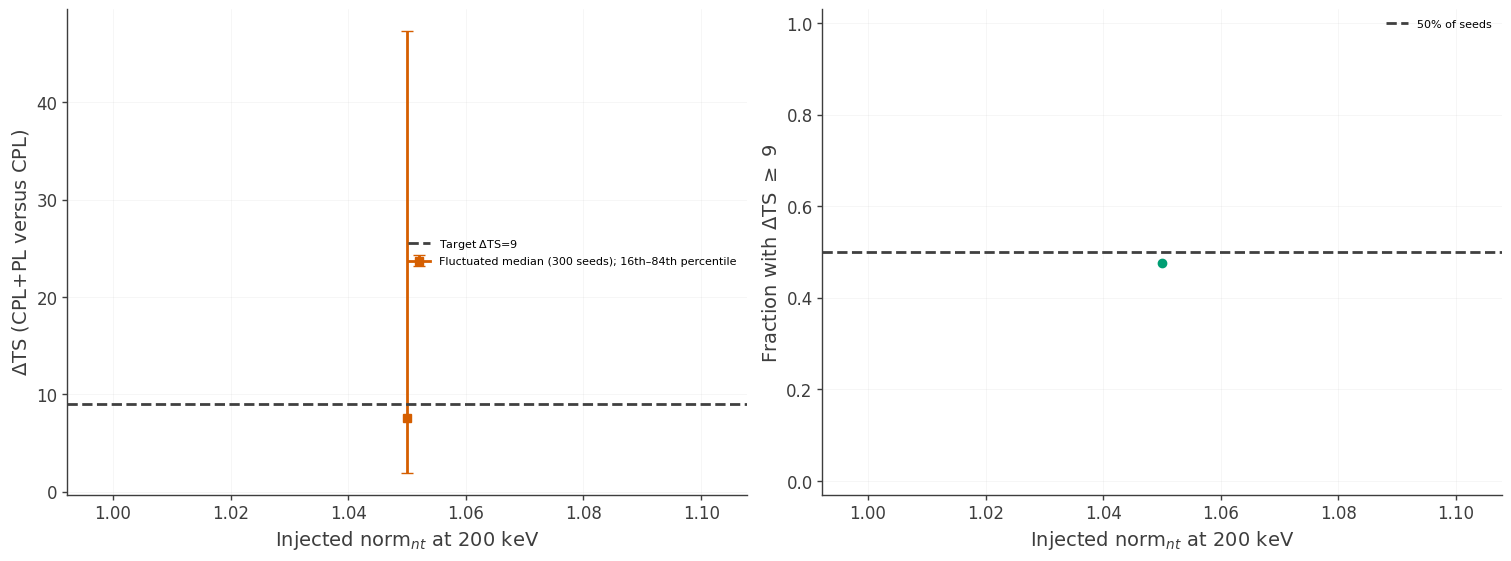

In [5]:
comparison_df = fluctuated_summary_df.sort_values("norm_nt").copy()

median_ts = comparison_df["median_delta_ts"].to_numpy()
median_ts_error = np.vstack([
    median_ts - comparison_df["delta_ts_q16"].to_numpy(),
    comparison_df["delta_ts_q84"].to_numpy() - median_ts,
])

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)
axes[0].errorbar(
    comparison_df["norm_nt"], median_ts, yerr=median_ts_error,
    fmt="s-", capsize=4, color="#D55E00",
    label=f"Fluctuated median ({fluctuated_n_seeds} seeds); 16th–84th percentile",
)
axes[0].axhline(
    target_delta_ts, color="0.25", ls="--",
    label=fr"Target $\Delta$TS={target_delta_ts:g}",
)
axes[0].set_xlabel(r"Injected $\mathrm{norm}_{nt}$ at 200 keV")
axes[0].set_ylabel(r"$\Delta$TS (CPL+PL versus CPL)")
axes[0].grid(alpha=0.2)
axes[0].legend(frameon=False)

axes[1].plot(
    comparison_df["norm_nt"],
    comparison_df["fraction_delta_ts_ge_target"],
    "o-", color="#009E73",
)
axes[1].axhline(0.5, color="0.25", ls="--", label="50% of seeds")
axes[1].set_ylim(-0.03, 1.03)
axes[1].set_xlabel(r"Injected $\mathrm{norm}_{nt}$ at 200 keV")
axes[1].set_ylabel(fr"Fraction with $\Delta$TS $\geq$ {target_delta_ts:g}")
axes[1].grid(alpha=0.2)
axes[1].legend(frameon=False)

display(comparison_df[[
    "norm_nt", "median_delta_ts",
    "delta_ts_q16", "delta_ts_q84",
    "fraction_delta_ts_ge_target", "median_recovered_norm_nt",
]])
